In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [2]:
# === USER INPUT ===
excel_path = r"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Zeleros - Zeleros\Operaciones\4- E-drive\05- Projects\Meridian\05_Engineering_Design\02_Module\00_Cell\02_Modelling\Cell_ageing_RPT_with_fake_data.xlsx"  # <-- change to your actual Excel filename

# Read all sheet names
sheet_names = pd.ExcelFile(excel_path).sheet_names
print(f"Found {len(sheet_names)} sheets")

Found 15 sheets


In [5]:
# Collect all experiments
records = []
for sheet in sheet_names:
    df = pd.read_excel(excel_path, sheet_name=sheet)

    # Check if this is a cycling or storage sheet
    if sheet.lower().startswith("storage"):
        mode = "storage"
        # Extract features from name, e.g. "Storage_100SOC_30degC"
        m = re.match(r"Storage_(\d+)SOC_(\d+)degC", sheet)
        if not m:
            print(f"Could not parse sheet name: {sheet}")
            continue

        soc = int(m.group(1))
        temp = int(m.group(2))

        # Expect columns: "Day" and "Relative_capacity"
        for _, row in df.iterrows():
            records.append({
                "Mode": mode,
                "Cycle_or_Day": row["Day"],
                "Temperature": temp,
                "SOC_max": soc,
                "SOC_min": soc,  # same for storage
                "Charge_Crate": 0,
                "Discharge_Crate": 0,
                "Relative_capacity": row["Relative_capacity"]
            })

    else:
        mode = "cycling"
        # Example: "033C_05C_100-0SOC_25degC"
        m = re.match(r"(\d+)C_(\d+)C_(\d+)-(\d+)SOC_(\d+)degC", sheet)
        if not m:
            print(f"Could not parse sheet name: {sheet}")
            continue

        charge_c = parse_crate(m.group(1))
        discharge_c = parse_crate(m.group(2))
        soc_max = int(m.group(3))
        soc_min = int(m.group(4))
        temp = int(m.group(5))

        # Expect columns: "Cycle" and "Relative_capacity"
        for _, row in df.iterrows():
            records.append({
                "Mode": mode,
                "Cycle_or_Day": row["Cycle"],
                "Temperature": temp,
                "SOC_max": soc_max,
                "SOC_min": soc_min,
                "Charge_Crate": charge_c,
                "Discharge_Crate": discharge_c,
                "Relative_capacity": row["Relative_capacity"]
            })

# Combine everything into a single DataFrame
data = pd.DataFrame(records)

# Derived features
data["DOD"] = data["SOC_max"] - data["SOC_min"]
data["SOC"] = data[['SOC_max', 'SOC_min']].mean(axis=1)
# Check
print(data["Mode"].value_counts())
print(f"\nCombined dataset shape: {data.shape}")
data

Mode
cycling    105
storage     88
Name: count, dtype: int64

Combined dataset shape: (193, 10)


,Mode,Cycle_or_Day,Temperature,SOC_max,SOC_min,Charge_Crate,Discharge_Crate,Relative_capacity,DOD,SOC
0,cycling,0.0,10,100,0,0.33,0.5,100.00,100,50.0
1,cycling,100.0,10,100,0,0.33,0.5,98.88,100,50.0
2,cycling,200.0,10,100,0,0.33,0.5,98.18,100,50.0
3,cycling,300.0,10,100,0,0.33,0.5,97.62,100,50.0
4,cycling,400.0,10,100,0,0.33,0.5,96.99,100,50.0
...,...,...,...,...,...,...,...,...,...,...
188,storage,180.0,40,30,30,0.00,0.0,97.55,0,30.0
189,storage,210.0,40,30,30,0.00,0.0,97.30,0,30.0
190,storage,240.0,40,30,30,0.00,0.0,97.05,0,30.0
191,storage,270.0,40,30,30,0.00,0.0,96.90,0,30.0


In [4]:
def parse_crate(crate_str):
    """
    Parse C-rate from the sheet name.
    - Leading zero, 2 digits (e.g., "05C") -> divide by 10 => 0.5
    - Leading zero, 3 digits (e.g., "033C") -> divide by 100 => 0.33
    - No leading zero (e.g., "1C", "2C") -> as float
    """
    if len(crate_str) == 1:
        # single digit after stripping zeros: 1C, 2C
        return float(crate_str)
    elif len(crate_str) == 2:
        # e.g., "05" → 0.5
        return float(crate_str) / 10
    else:
        # e.g., "033" → 0.33
        return float(crate_str) / 100


In [10]:
cycling_df = data[data["Mode"] == "cycling"].copy()
storage_df = data[data["Mode"] == "storage"].copy()

print(f"Cycling samples: {len(cycling_df)}, Storage samples: {len(storage_df)}")

Cycling samples: 105, Storage samples: 88


In [11]:
def train_model(df, mode):
    # Select features
    if "storage" in mode.lower():
        features = ["Cycle_or_Day", "Temperature", "SOC"]
    else:
        features = ["Cycle_or_Day", "Temperature", "SOC_max", "SOC_min", "Charge_Crate", "Discharge_Crate"]

    X = df[features]
    y = df["Relative_capacity"]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=89)

    # Train
    model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=89)
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n--- {mode.upper()} MODEL ---")
    print(f"Samples: {len(df)}")
    print(f"MAE: {mae:.4f}")
    print(f"R²:  {r2:.4f}")

    return model, X_test, y_test, y_pred

cycling_model, Xc_test, yc_test, yc_pred = train_model(cycling_df, "cycling")
storage_model, Xs_test, ys_test, ys_pred = train_model(storage_df, "storage")



--- CYCLING MODEL ---
Samples: 105
MAE: 0.7659
R²:  0.9781

--- STORAGE MODEL ---
Samples: 88
MAE: 0.2162
R²:  0.9549


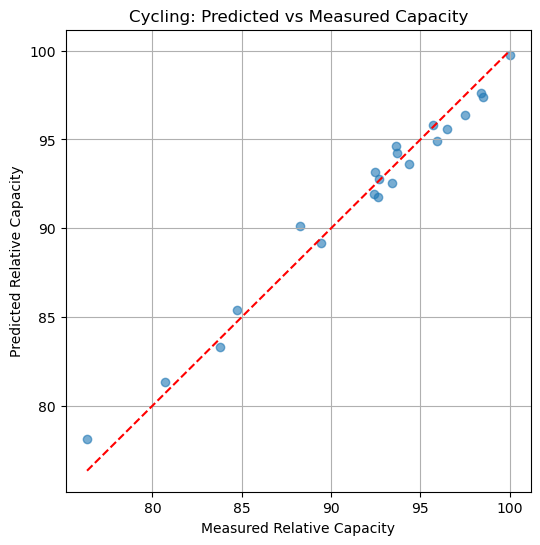

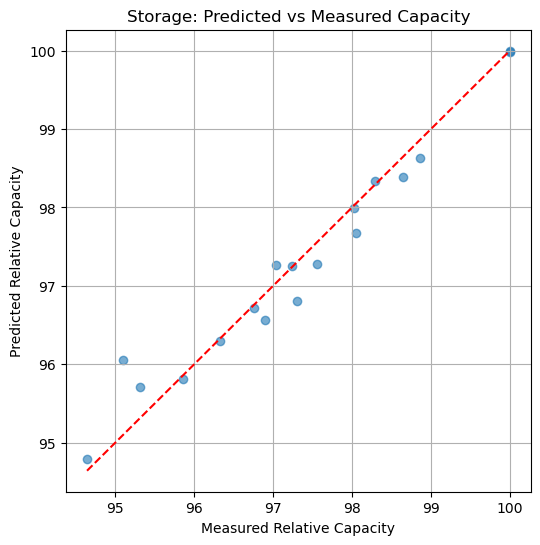

In [12]:
def plot_pred_vs_true(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Measured Relative Capacity")
    plt.ylabel("Predicted Relative Capacity")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_pred_vs_true(yc_test, yc_pred, "Cycling: Predicted vs Measured Capacity")
plot_pred_vs_true(ys_test, ys_pred, "Storage: Predicted vs Measured Capacity")


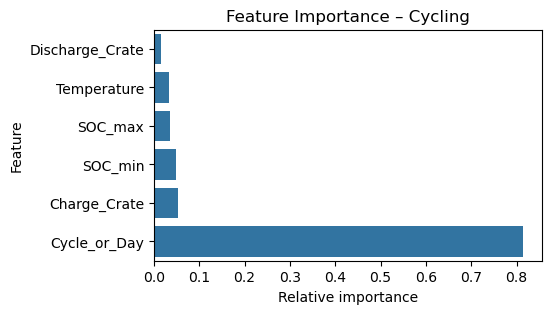

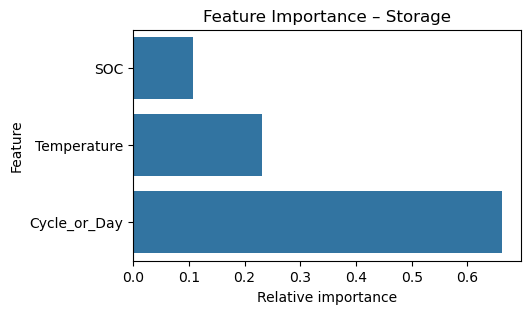

In [13]:
def show_importance(model, features, title):
    imp = pd.Series(model.feature_importances_, index=features).sort_values()
    plt.figure(figsize=(5,3))
    sns.barplot(x=imp, y=imp.index)
    plt.title(f"Feature Importance – {title}")
    plt.xlabel("Relative importance")
    plt.ylabel("Feature")
    plt.show()

show_importance(cycling_model, ["Cycle_or_Day", "Temperature", "SOC_max", "SOC_min", "Charge_Crate", "Discharge_Crate"], "Cycling")
show_importance(storage_model, ["Cycle_or_Day", "Temperature", "SOC"], "Storage")


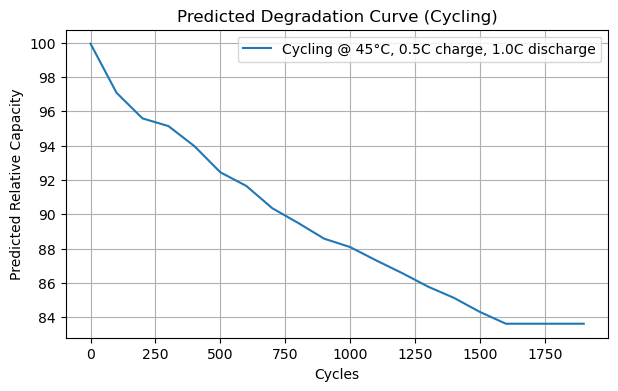

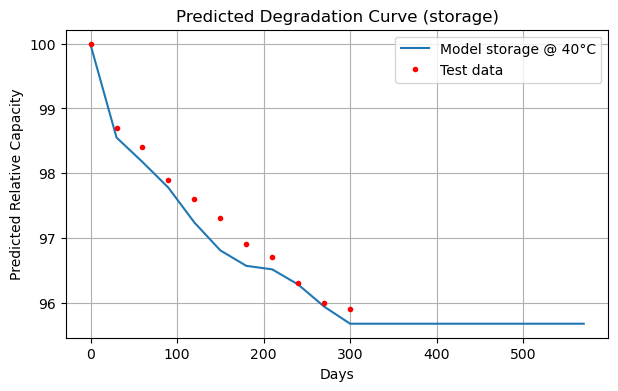

In [15]:
def predict_capacity_curve(model, mode, cycles_or_days, temp, soc=0, soc_max=0, soc_min=0, charge_c_rate=0, discharge_c_rate=0):
    if "storage" in mode.lower():
        df_pred = pd.DataFrame({
        "Cycle_or_Day": cycles_or_days,
        "Temperature": [temp]*len(cycles_or_days),
        "SOC": [soc]*len(cycles_or_days),
        })
    else:
        df_pred = pd.DataFrame({
            "Cycle_or_Day": cycles_or_days,
            "Temperature": [temp]*len(cycles_or_days),
            "SOC_max": [soc_max]*len(cycles_or_days),
            "SOC_min": [soc_min]*len(cycles_or_days),
            "Charge_Crate": [charge_c_rate]*len(cycles_or_days),
            "Discharge_Crate": [discharge_c_rate]*len(cycles_or_days)
        })
    pred_cap = model.predict(df_pred)
    return pred_cap

# Example: simulate cycling at 45°C, 100% DOD, 0.5C charge, 1C discharge
mode = "Cycling"
cycles = np.arange(0,2000,100)
temperature = 45
soc_max = 100
soc_max = 0
charge_rate = 0.5
discharge_rate = 1
predicted_capacity = predict_capacity_curve(cycling_model, mode, cycles_or_days=cycles, temp=temperature, soc_max=soc_max, soc_min=soc_min, charge_c_rate=charge_rate, discharge_c_rate=discharge_rate)
plt.figure(figsize=(7,4))
plt.plot(cycles, predicted_capacity, label=f"{mode} @ {temperature}°C, {charge_rate:.1f}C charge, {discharge_rate:.1f}C discharge")
plt.xlabel("Cycles")
plt.ylabel("Predicted Relative Capacity")
plt.title(f"Predicted Degradation Curve ({mode})")
plt.legend()
plt.grid(True)
plt.show()

# Example: simulate storage at 30°C, 100% SOC
mode = "storage"
days = np.arange(0,600,30)
temperature = 30
soc = 100
test_data = data.loc[(data['Mode'] == mode.lower()) & (data['Temperature'] == temperature) & (data['SOC'] == soc)]
predicted_capacity = predict_capacity_curve(storage_model, mode, cycles_or_days=days, temp=temperature, soc=soc)
plt.figure(figsize=(7,4))
plt.plot(days, predicted_capacity, label=f"Model {mode} @ {temp}°C")
plt.plot(test_data["Cycle_or_Day"], test_data["Relative_capacity"], 'r.', label="Test data")
plt.xlabel("Days")
plt.ylabel("Predicted Relative Capacity")
plt.title(f"Predicted Degradation Curve ({mode})")
plt.legend()
plt.grid(True)
plt.show()

In [114]:
mode = "Storage"
temperature = 40
soc = 100
test_data = data.loc[(data['Mode'] == mode.lower()) & (data['Temperature'] == temperature) & (data['SOC'] == soc)]
test_data

,Mode,Cycle_or_Day,Temperature,SOC_max,SOC_min,Charge_Crate,Discharge_Crate,Relative_capacity,DOD,SOC
116,storage,0.0,40,100,100,0.0,0.0,100.0,0,100.0
117,storage,30.0,40,100,100,0.0,0.0,98.1,0,100.0
118,storage,60.0,40,100,100,0.0,0.0,97.3,0,100.0
119,storage,90.0,40,100,100,0.0,0.0,96.7,0,100.0
120,storage,120.0,40,100,100,0.0,0.0,96.1,0,100.0
121,storage,150.0,40,100,100,0.0,0.0,95.4,0,100.0
122,storage,180.0,40,100,100,0.0,0.0,95.1,0,100.0
123,storage,210.0,40,100,100,0.0,0.0,94.6,0,100.0
124,storage,240.0,40,100,100,0.0,0.0,94.1,0,100.0
125,storage,270.0,40,100,100,0.0,0.0,93.8,0,100.0


In [113]:
data

,Mode,Cycle_or_Day,Temperature,SOC_max,SOC_min,Charge_Crate,Discharge_Crate,Relative_capacity,DOD,SOC
0,cycling,0.0,10,100,0,0.33,0.5,100.00,100,50.0
1,cycling,100.0,10,100,0,0.33,0.5,98.88,100,50.0
2,cycling,200.0,10,100,0,0.33,0.5,98.18,100,50.0
3,cycling,300.0,10,100,0,0.33,0.5,97.62,100,50.0
4,cycling,400.0,10,100,0,0.33,0.5,96.99,100,50.0
...,...,...,...,...,...,...,...,...,...,...
188,storage,180.0,40,30,30,0.00,0.0,97.55,0,30.0
189,storage,210.0,40,30,30,0.00,0.0,97.30,0,30.0
190,storage,240.0,40,30,30,0.00,0.0,97.05,0,30.0
191,storage,270.0,40,30,30,0.00,0.0,96.90,0,30.0
